# System Definition

## Cat Qubit Calibration Framework

This notebook presents the core physics and mathematics behind our cat qubit calibration system.

## 1. The Hamiltonian: System Dynamics

Cat qubits are dissipative quantum systems built on two modes:
- **Storage mode** ($a, a^\dagger$): stores the quantum information
- **Buffer mode** ($b, b^\dagger$): supports the two-photon pumping

### Standard Cat Qubit Hamiltonian

$$H = g_2^* a^\dagger a^\dagger b + g_2 a a b^\dagger - \varepsilon_d b^\dagger - \varepsilon_d^* b + \text{drift}$$

Where:
- $g_2$: two-photon coupling strength (complex, tunable parameter)
- $\varepsilon_d$: buffer drive amplitude (complex, tunable parameter)
- Drift terms model environmental fluctuations in amplitude or frequency

### Dissipation (Jump Operators)

The system is open; information leaks through two channels:

$$L_a = \sqrt{\kappa_a} \, a \quad \text{(storage loss)}$$
$$L_b = \sqrt{\kappa_b} \, b \quad \text{(buffer loss)}$$

Typical values: $\kappa_b = 10.0$, $\kappa_a = 1.0$ (storage is much more stable).

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import jax.numpy as jnp
import dynamiqs as dq

# Physical parameters (typical values)
NA = 12          # storage mode Hilbert space dimension
NB = 4           # buffer mode Hilbert space dimension
KAPPA_B = 10.0   # buffer loss rate
KAPPA_A = 1.0    # storage loss rate

def build_standard_cat(knobs, drift_amp=0.0, drift_delta=0.0):
    """
    Build the standard cat qubit Hamiltonian.
    
    Parameters
    ----------
    knobs : array
        [g2_re, g2_im, eps_d_re, eps_d_im] - control parameters
    drift_amp : float
        Amplitude fluctuation multiplicative factor
    drift_delta : float
        Frequency detuning additive shift
    
    Returns
    -------
    H : Hamiltonian
    [loss_b, loss_a] : list of jump operators
    """
    # Create annihilation operators
    a = dq.tensor(dq.destroy(NA), dq.eye(NB))  # storage
    b = dq.tensor(dq.eye(NA), dq.destroy(NB))  # buffer
    
    # Parse control parameters
    g2 = knobs[0] + 1j * knobs[1]              # two-photon coupling
    eps_d = knobs[2] + 1j * knobs[3]           # buffer drive
    
    # Include amplitude drift if present
    g2_drifted = g2 * (1 + drift_amp)
    
    # Build Hamiltonian: H = g2* a†a†b + g2 aa†b - eps_d b† - eps_d* b + drift_delta a†a
    H = (jnp.conj(g2_drifted) * a @ a @ b.dag()        # conjugate coupling
         + g2_drifted * a.dag() @ a.dag() @ b          # two-photon pumping
         - eps_d * b.dag() - jnp.conj(eps_d) * b       # buffer drive
         + drift_delta * a.dag() @ a)                   # frequency drift
    
    # Jump operators (dissipation channels)
    loss_b = jnp.sqrt(KAPPA_B) * b
    loss_a = jnp.sqrt(KAPPA_A) * a
    
    return H, [loss_b, loss_a], a, b

# Example: default parameters
knobs_default = jnp.array([1.0, 0.0, 4.0, 0.0])
H, [loss_b, loss_a], a, b = build_standard_cat(knobs_default)

print("Standard Cat Hamiltonian built successfully.")
print(f"Storage mode dimension: {NA}")
print(f"Buffer mode dimension: {NB}")
print(f"Control parameters (knobs): g2_re={knobs_default[0]}, g2_im={knobs_default[1]}, eps_d_re={knobs_default[2]}, eps_d_im={knobs_default[3]}")
print(f"\nTypical loss rates:")
print(f"  κ_b = {KAPPA_B} (buffer)")
print(f"  κ_a = {KAPPA_A} (storage)")

Standard Cat Hamiltonian built successfully.
Storage mode dimension: 12
Buffer mode dimension: 4
Control parameters (knobs): g2_re=1.0, g2_im=0.0, eps_d_re=4.0, eps_d_im=0.0

Typical loss rates:
  κ_b = 10.0 (buffer)
  κ_a = 1.0 (storage)


### Model Variants

We explore **5 different cat qubit models**, each with different physics and control capabilities:

| Model | Knobs | Extra Physics | Use Case |
|-------|-------|--------------|----------|
| **Standard Cat** | 4 | Baseline two-photon pumping | Reference configuration |
| **Moon Cat** | 6 | Additional $a^\dagger a b$ coupling | Extended control |
| **Drift-Compensated** | 5 | Tunable detuning $\Delta_d$ to correct drift | Robustness to environmental shifts |
| **Kerr Cat** | 5 | Kerr nonlinearity $K a^\dagger a^\dagger a a$ | Improved coherence |
| **Effective Single-Mode** | 2 | Reduced Hilbert space (buffer = 1 dimension) | Fast computation |

Each model is registered in `src/models.py` and can be selected at optimization runtime.

### Standard-Cat Wigner Evolution

A key visual signature of the cat qubit is its phase-space interference structure. To make the physics concrete, we evolve a standard cat state and display the Wigner function over time.

For this demonstration we use the project Wigner helper on a standard-cat Hamiltonian with a short evolution time and a `+x` initial state, since the interference fringes are most visible in the superposition basis.

Saved GIF to temp directory: C:\Users\david\AppData\Local\Temp\standard_cat_wigner.gif


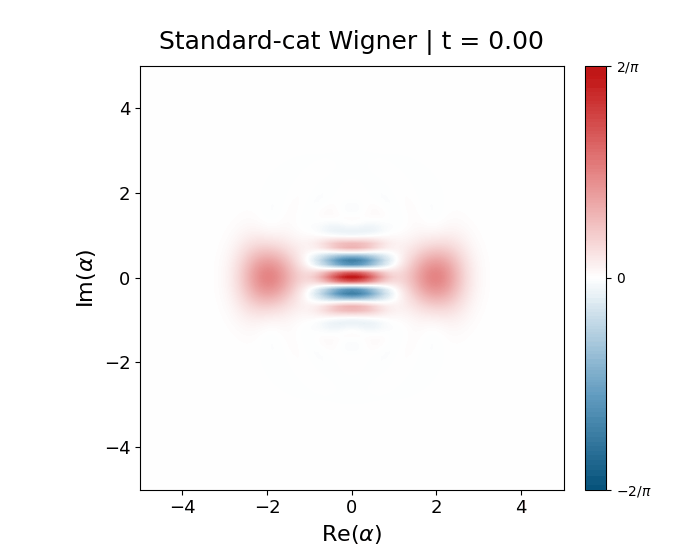

In [8]:
import sys
import tempfile
from pathlib import Path

import dynamiqs as dq
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
from IPython.display import HTML, Image, display

repo_root = Path.cwd().parent
src_root = repo_root / "src"
for candidate in (repo_root, src_root):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

import static_hamiltonians as statH

data_build_wigner = {
    "Hilbert_space_large": 12,
    "Hilbert_space_cutted_for_solution": 4,
    "knobs": [1.0, 0.0, 4.0, 0.0],
}

H_wigner = statH.build_standard_cat(data_build_wigner)
na = data_build_wigner["Hilbert_space_large"]
nb = data_build_wigner["Hilbert_space_cutted_for_solution"]
a = dq.tensor(dq.destroy(na), dq.eye(nb))
b = dq.tensor(dq.eye(na), dq.destroy(nb))

alpha = 2.0
g_state = dq.coherent(na, alpha)
e_state = dq.coherent(na, -alpha)
psi0 = dq.tensor((g_state + e_state) / jnp.sqrt(2), dq.fock(nb, 0))

# Use more frames for a smoother animation.
tsave = jnp.linspace(0.0, 0.8, 40)
res = dq.mesolve(
    H_wigner,
    [jnp.sqrt(10.0) * b, jnp.sqrt(1.0) * a],
    psi0,
    tsave,
    options=dq.Options(progress_meter=False),
    method=dq.method.Tsit5(),
)

dm_reduced_series = []
for state in res.states:
    dm_full = np.array(state @ state.dag())
    dm_reduced = np.trace(dm_full.reshape(na, nb, na, nb), axis1=1, axis2=3)
    dm_reduced_series.append(dm_reduced)

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.subplots_adjust(right=0.88)

title_fs = 18
label_fs = 16
tick_fs = 13
cbar_label_fs = 15
cbar_tick_fs = 12

def update(frame_idx):
    # Remove prior colorbar axis so we do not accumulate one per frame.
    while len(fig.axes) > 1:
        fig.axes[-1].remove()

    ax.clear()
    dq.plot.wigner(dm_reduced_series[frame_idx], ax=ax, colorbar=True)
    ax.set_title(f"Standard-cat Wigner | t = {float(tsave[frame_idx]):.2f}", fontsize=title_fs, pad=12)
    ax.set_xlabel(r"Re($\alpha$)", fontsize=label_fs)
    ax.set_ylabel(r"Im($\alpha$)", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)

    if len(fig.axes) > 1:
        cax = fig.axes[-1]
        cax.set_ylabel("Wigner value", fontsize=cbar_label_fs)
        cax.tick_params(labelsize=cbar_tick_fs)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(tsave),
    interval=120,
    blit=False,
    repeat=True,
    repeat_delay=500,
    cache_frame_data=False,
)

gif_filename = "standard_cat_wigner.gif"
primary_path = Path.cwd() / gif_filename
fallback_path = Path(tempfile.gettempdir()) / gif_filename

try:
    ani.save(str(primary_path), writer=animation.PillowWriter(fps=8))
    print(f"Saved GIF to: {primary_path.resolve()}")
    display(Image(filename=str(primary_path)))
except FileNotFoundError:
    ani.save(str(fallback_path), writer=animation.PillowWriter(fps=8))
    print(f"Saved GIF to temp directory: {fallback_path}")
    display(Image(filename=str(fallback_path)))
except Exception as exc:
    print(f"GIF file export failed ({exc}). Showing inline HTML animation instead.")
    display(HTML(ani.to_jshtml()))
finally:
    plt.close(fig)

---

## 2. The Reward Function: Optimization Objective

### Qubit Quality Metrics

We measure two independent lifetimes via master-equation simulation:

- **$T_Z$**: Decay time of the $|+z\rangle$ state (logical state protection)  
  Measured via expectation value $\langle \sigma_z \rangle(t) \approx e^{-t/T_Z}$

- **$T_X$**: Coherence time of the $|+x\rangle$ state (superposition coherence)  
  Measured via parity $\langle e^{i\pi a^\dagger a} \rangle(t) \approx e^{-t/T_X}$

- **Bias**: $\eta = T_Z / T_X$  
  Ratio capturing the imbalance between state protection and superposition coherence.  
  Goal: maximize both lifetimes while achieving a **target bias** (e.g., 100:1 or 500:1).

### Reward Functions

We implement a **family of objective functions** balancing multiple goals. All use the registry `OBJECTIVES` in `src/objectives.py`.

In [9]:
import jax.numpy as jnp

def log_sum_penalty(T_Z, T_X, target_bias, lambda_penalty, **_):
    """
    Default reward: sum of log-lifetimes with quadratic bias penalty.
    
    R = ln(T_Z) + ln(T_X) - λ * (η - η₀)²
    
    Rewards large lifetimes (log scale) while penalizing bias mismatch.
    """
    eta = T_Z / jnp.maximum(T_X, 1e-6)
    reward = jnp.log(T_Z) + jnp.log(T_X) - lambda_penalty * (eta - target_bias) ** 2
    return float(reward)


def weighted_log(T_Z, T_X, target_bias, lambda_penalty, w_Z=1.0, w_X=100.0, **_):
    """
    Prioritize coherence time: weight T_X more heavily.
    
    R = w_Z·ln(T_Z) + w_X·ln(T_X) - λ * (η - η₀)²
    """
    eta = T_Z / jnp.maximum(T_X, 1e-6)
    reward = w_Z * jnp.log(T_Z) + w_X * jnp.log(T_X) - lambda_penalty * (eta - target_bias) ** 2
    return float(reward)


def bias_prioritized(T_Z, T_X, target_bias, lambda_penalty=0.01, tolerance=10.0, gamma=1.0, **_):
    """
    Soft constraint on bias: only penalize significant deviations.
    
    R = ln(T_Z) - γ * max(|η - η₀| - ε, 0)
    """
    eta = T_Z / jnp.maximum(T_X, 1e-6)
    bias_penalty = gamma * jnp.maximum(jnp.abs(eta - target_bias) - tolerance, 0)
    return float(jnp.log(T_Z) - bias_penalty)


def bias_constrained(T_Z, T_X, target_bias, lambda_penalty=0.01, tolerance=10.0, **_):
    """
    Hard constraint on bias: reject solutions outside tolerance window.
    
    R = ln(T_Z)  if |η - η₀| < ε,  else  -∞
    """
    eta = T_Z / jnp.maximum(T_X, 1e-6)
    bias_error = jnp.abs(eta - target_bias)
    return float(jnp.log(T_Z)) if float(bias_error) < tolerance else -1e6


def log_relative_penalty(T_Z, T_X, target_bias, lambda_penalty=0.001, **_):
    """
    Log-space bias penalty: penalize relative (multiplicative) bias error.
    
    R = ln(T_Z) + ln(T_X) - λ * (ln(η) - ln(η₀))²
    """
    eta = T_Z / jnp.maximum(T_X, 1e-6)
    reward = (jnp.log(T_Z) + jnp.log(T_X) 
              - lambda_penalty * (jnp.log(eta) - jnp.log(target_bias)) ** 2)
    return float(reward)


# Summary table
OBJECTIVES = {
    "log_sum_penalty": {
        "label": "Log sum + quadratic bias penalty",
        "fn": log_sum_penalty,
        "eq": "R = ln(T_Z) + ln(T_X) − λ·(η − η₀)²",
        "description": "Balanced: maximize both lifetimes, penalize bias mismatch."
    },
    "weighted_log": {
        "label": "Weighted log sum + quadratic bias penalty",
        "fn": weighted_log,
        "eq": "R = w_Z·ln(T_Z) + w_X·ln(T_X) − λ·(η − η₀)²",
        "description": "Prioritize coherence (T_X) if w_X > w_Z."
    },
    "bias_prioritized": {
        "label": "Bias-prioritized (tolerance + linear penalty)",
        "fn": bias_prioritized,
        "eq": "R = ln(T_Z) − γ·max(|η − η₀| − ε, 0)",
        "description": "Soft constraint: only penalize large bias deviations."
    },
    "bias_constrained": {
        "label": "Bias hard constraint",
        "fn": bias_constrained,
        "eq": "R = ln(T_Z)  if |η − η₀| < ε  else  −∞",
        "description": "Strict: reject solutions outside bias window."
    },
    "log_relative_penalty": {
        "label": "Log sum + relative bias penalty",
        "fn": log_relative_penalty,
        "eq": "R = ln(T_Z) + ln(T_X) − λ·(ln(η) − ln(η₀))²",
        "description": "Log-space: penalize multiplicative bias error."
    },
}

print("Reward Functions Summary:")
print("=" * 80)
for name, config in OBJECTIVES.items():
    print(f"\n{name}:")
    print(f"  Label: {config['label']}")
    print(f"  Equation: {config['eq']}")
    print(f"  Description: {config['description']}")

Reward Functions Summary:

log_sum_penalty:
  Label: Log sum + quadratic bias penalty
  Equation: R = ln(T_Z) + ln(T_X) − λ·(η − η₀)²
  Description: Balanced: maximize both lifetimes, penalize bias mismatch.

weighted_log:
  Label: Weighted log sum + quadratic bias penalty
  Equation: R = w_Z·ln(T_Z) + w_X·ln(T_X) − λ·(η − η₀)²
  Description: Prioritize coherence (T_X) if w_X > w_Z.

bias_prioritized:
  Label: Bias-prioritized (tolerance + linear penalty)
  Equation: R = ln(T_Z) − γ·max(|η − η₀| − ε, 0)
  Description: Soft constraint: only penalize large bias deviations.

bias_constrained:
  Label: Bias hard constraint
  Equation: R = ln(T_Z)  if |η − η₀| < ε  else  −∞
  Description: Strict: reject solutions outside bias window.

log_relative_penalty:
  Label: Log sum + relative bias penalty
  Equation: R = ln(T_Z) + ln(T_X) − λ·(ln(η) − ln(η₀))²
  Description: Log-space: penalize multiplicative bias error.


### Online Optimizer Review

The online optimizer implemented in `optimizer.py` follows a repeated closed loop:

1. **Initialize** a CMA-ES search distribution around the model's default knob values.
2. **Ask** for a batch of candidate knob settings from the current distribution.
3. **Evaluate** each candidate by building the Hamiltonian, simulating the dynamics, and measuring $T_Z$, $T_X$, and bias.
4. **Score** each candidate with one of the reward functions defined above.
5. **Tell** the optimizer the rewards so it updates its sampling distribution.
6. **Repeat** under the current drift condition, tracking reward, $T_Z$, $T_X$, and $\eta$ over epochs.

This is what makes the procedure online: the control distribution is updated after every evaluation batch rather than after a fixed offline parameter sweep.

### Parameter Tuning Via Knobs

Each model exposes control parameters that adjust the Hamiltonian:
- **Two-photon coupling** $g_2 = g_2^{\text{re}} + i \cdot g_2^{\text{im}}$
- **Buffer drive** $\varepsilon_d = \varepsilon_d^{\text{re}} + i \cdot \varepsilon_d^{\text{im}}$
- Model-specific extras such as Kerr strength, moon-cat coupling, or detuning compensation

The optimizer tunes these knobs to maximize reward while adapting to the active drift model.

In [10]:
import numpy as np

# Example: how reward varies with lifetimes
target_bias = 100.0
lambda_penalty = 0.001

# Test cases
test_cases = [
    {"name": "Poor", "T_Z": 10.0, "T_X": 0.05},    # Short lifetimes
    {"name": "Moderate", "T_Z": 100.0, "T_X": 0.8},  # Medium, good bias
    {"name": "Good", "T_Z": 200.0, "T_X": 2.0},      # Long, target bias
    {"name": "High Bias", "T_Z": 500.0, "T_X": 2.0}, # Long, η = 250 (too high)
    {"name": "Ideal", "T_Z": 500.0, "T_X": 5.0},     # Long, η = 100 (perfect)
]

print("Reward Comparison Across Different Scenarios")
print("=" * 100)
print(f"Target bias (η₀) = {target_bias}, λ = {lambda_penalty}\n")

# Header
print(f"{'Scenario':<15} {'T_Z':<10} {'T_X':<10} {'η':<12} {'log_sum_penalty':<18} {'weighted_log':<15}")
print("-" * 100)

for tc in test_cases:
    T_Z = tc["T_Z"]
    T_X = tc["T_X"]
    eta = T_Z / T_X
    
    reward_ls = log_sum_penalty(T_Z, T_X, target_bias, lambda_penalty)
    reward_wl = weighted_log(T_Z, T_X, target_bias, lambda_penalty, w_Z=1.0, w_X=100.0)
    
    print(f"{tc['name']:<15} {T_Z:<10.1f} {T_X:<10.2f} {eta:<12.1f} {reward_ls:<18.3f} {reward_wl:<15.3f}")

print("\n" + "=" * 100)
print("Observations:")
print("- High T_Z, T_X → larger ln sums → higher reward")
print("- Bias penalty grows with (η - η₀)² → matches target bias for best reward")
print("- weighted_log example weights T_X 100x more, making coherence critical")
print("- Choose objective based on your calibration priorities!")

Reward Comparison Across Different Scenarios
Target bias (η₀) = 100.0, λ = 0.001

Scenario        T_Z        T_X        η            log_sum_penalty    weighted_log   
----------------------------------------------------------------------------------------------------
Poor            10.0       0.05       200.0        -10.693            -307.271       
Moderate        100.0      0.80       125.0        3.757              -18.334        
Good            200.0      2.00       100.0        5.991              74.613         
High Bias       500.0      2.00       250.0        -15.592            53.029         
Ideal           500.0      5.00       100.0        7.824              167.158        

Observations:
- High T_Z, T_X → larger ln sums → higher reward
- Bias penalty grows with (η - η₀)² → matches target bias for best reward
- weighted_log example weights T_X 100x more, making coherence critical
- Choose objective based on your calibration priorities!


---

## 3. Worked Example: Measure $T_Z$ and $T_X$

This example follows the workflow in the developer README: build a Hamiltonian from the project modules, assemble the simulation dictionary, and call `measure_lifetime(data)`.

The key point is that the returned lifetime depends on the chosen initial state:
- `initial_state = "+z"` measures **$T_Z$**
- `initial_state = "+x"` measures **$T_X$**

Below we evaluate both lifetimes for a static standard cat, then compare them with a drifted Hamiltonian example.

In [11]:
import sys
from pathlib import Path

import jax.numpy as jnp

repo_root = Path.cwd().parent
src_root = repo_root / "src"
for candidate in (repo_root, src_root):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

import static_hamiltonians as statH
import drift_hamiltonians as driftH
from Model_to_halflife import measure_lifetime

data_build_static = {
    "Hilbert_space_large": 15,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
}

H_static = statH.build_standard_cat(data_build_static)

data_static_tz = {
    **data_build_static,
    "initial_state": "+z",
    "Hamiltonian": H_static,
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    "tfinal": 5.0,
    "plot": False,
}
T_Z_static, _ = measure_lifetime(data_static_tz)

data_static_tx = {
    **data_build_static,
    "initial_state": "+x",
    "Hamiltonian": H_static,
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    "tfinal": 1.0,
    "plot": False,
}
T_X_static, _ = measure_lifetime(data_static_tx)

data_build_dynamic = {
    "Hilbert_space_large": 15,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.05],
}

H_dynamic = driftH.build_amplitude_drift(data_build_dynamic)

data_dynamic_tz = {
    **data_build_dynamic,
    "initial_state": "+z",
    "Hamiltonian": H_dynamic,
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    "tfinal": 5.0,
    "plot": False,
}
T_Z_dynamic, _ = measure_lifetime(data_dynamic_tz)

data_dynamic_tx = {
    **data_build_dynamic,
    "initial_state": "+x",
    "Hamiltonian": H_dynamic,
    "kappa_a": 1.0,
    "kappa_b": 10.0,
    "tfinal": 1.0,
    "plot": False,
}
T_X_dynamic, _ = measure_lifetime(data_dynamic_tx)

bias_static = float(T_Z_static) / max(float(T_X_static), 1e-6)
bias_dynamic = float(T_Z_dynamic) / max(float(T_X_dynamic), 1e-6)

print("Worked Example Results")
print("=" * 54)
print(f"Static standard cat: T_Z = {float(T_Z_static):.4f}, T_X = {float(T_X_static):.4f}, bias = {bias_static:.2f}")
print(f"Dynamic amplitude drift: T_Z = {float(T_Z_dynamic):.4f}, T_X = {float(T_X_dynamic):.4f}, bias = {bias_dynamic:.2f}")

c:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\equinox\_module\_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Worked Example Results
Static standard cat: T_Z = 6.9416, T_X = 0.1785, bias = 38.88
Dynamic amplitude drift: T_Z = 193.0980, T_X = 0.1791, bias = 1078.00


c:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\equinox\_module\_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


### Tunable Detuning Comparison

One of the main robustness ideas in this project is to add a tunable detuning term $\Delta a^\dagger a$ so the controller can compensate part of the drift instead of only reacting through the original cat-qubit knobs.

For a short notebook demonstration, we compare the coherence-time measurement $T_X$ under frequency drift with and without the additional detuning knob. The compensated model uses `drift_hamiltonian_correction_extentions.py`.

In [12]:
import sys
from pathlib import Path

import jax.numpy as jnp

repo_root = Path.cwd().parent
src_root = repo_root / "src"
for candidate in (repo_root, src_root):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

import drift_hamiltonians as driftH
import drift_hamiltonian_correction_extentions as driftCorr
from Model_to_halflife import measure_lifetime

baseline_build = {
    "Hilbert_space_large": 14,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0],
    "drift_params": [0.25, 2.0 * jnp.pi, 0.0],
}
H_baseline = driftH.build_frequency_drift(baseline_build)

compensated_build = {
    "Hilbert_space_large": 14,
    "Hilbert_space_cutted_for_solution": 5,
    "knobs": [1.0, 0.0, 4.0, 0.0, 0.35],
    "drift_params": [0.25, 2.0 * jnp.pi, 0.0],
}
H_compensated = driftCorr.build_frequency_drift(compensated_build)

def measure_tx(data_build, H):
    data = {
        **data_build,
        "initial_state": "+x",
        "Hamiltonian": H,
        "kappa_a": 1.0,
        "kappa_b": 10.0,
        "tfinal": 1.0,
        "plot": False,
    }
    T_X, _ = measure_lifetime(data)
    return float(T_X)

baseline_tx = measure_tx(baseline_build, H_baseline)
comp_tx = measure_tx(compensated_build, H_compensated)
relative_gain = 100.0 * (comp_tx - baseline_tx) / max(baseline_tx, 1e-6)

print("Detuning Comparison (T_X under frequency drift)")
print("=" * 54)
print(f"Without detuning knob:  T_X = {baseline_tx:.4f}")
print(f"With tunable Δ_d:       T_X = {comp_tx:.4f}")
print(f"Relative change:        {relative_gain:+.2f}%")

c:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\equinox\_module\_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Detuning Comparison (T_X under frequency drift)
Without detuning knob:  T_X = 0.1777
With tunable Δ_d:       T_X = 0.1755
Relative change:        -1.25%


---

## End: Main Takeaway and Next Step

The notebook now shows the core story of the project: define the cat-qubit physics, visualize the state structure in phase space, compare reward functions, and connect those ingredients to an online calibration loop.

The main lesson is that calibration is not only about maximizing a single lifetime. We need to balance $T_Z$, $T_X$, and bias while staying robust to drift and model mismatch.

A natural next extension, which was out of time during the hackathon, is to carry the same adaptive-calibration ideas into **single-qubit gate design and calibration**.